In [1]:
from HARey_constellation_cards.harey_main import HAReyMain

harey = HAReyMain()

Loading constellations diagrams....     Done!
Loading star coordinates....     Done!
Computing stars colors...     Done!
Loading custom markers....       Done!
Loading the object names....       Done!


Using the tarot-round format, 2.75x4.75 in, using the template at cardbacks/tarot_round.png


In [2]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, PathPatch
from matplotlib.path import Path
import numpy as np

# IMPORTANTE
### NORTHERN EMISPHERE
Hour disk: anticlockwise, 12 to SOUTH
Day disk: clockwise, MARCH 20 to RA 0
### SOUTHERN EMISPHERE
Hour disk: clockwise, 12 to NORTH
Day disk: anticlockwise, MARCH 20 to RA 0


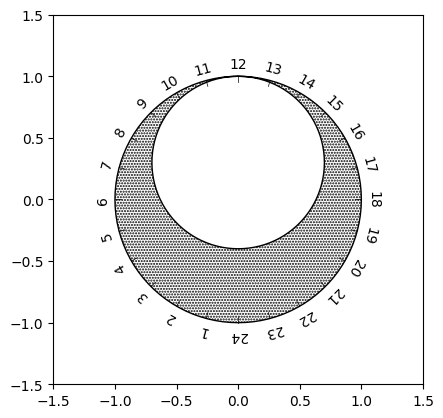

In [3]:
a = np.linspace(0, 2*np.pi, 101)
vertices = []
codes = []

# f flips the plot left and right, depending on the hemisphere
HEMISPHERE = 'S'
f = 1 if HEMISPHERE == 'N' else -1

# Outer circle points
circle = np.array((np.sin(a), np.cos(a))).transpose()
vertices.extend(circle)
codes.extend([Path.MOVETO] + [Path.LINETO]*(circle.shape[0]-2) + [Path.CLOSEPOLY])

# The internal circle is made anticlockwise to create the empty shape
cutout = np.array((0.7*np.sin(-a), 0.3+ 0.7*np.cos(-a))).transpose()
vertices.extend(cutout)
codes.extend([Path.MOVETO] + [Path.LINETO]*(cutout.shape[0]-2) + [Path.CLOSEPOLY])

# Join the two paths into a patch
mask = Path(vertices, codes)
mask = PathPatch(mask, hatch='......', fill=None)

fig, ax = plt.subplots(nrows=1, ncols=1)
# Add the hours marker
for i in range(1,25):
    a = f*i/12*np.pi
    ax.plot((1*np.sin(a),0.95*np.sin(a)), (1*np.cos(a),0.95*np.cos(a)), c='k', lw=0.5)
    ax.text(1.1*np.sin(a), -1.1*np.cos(a), f'{i}', rotation = 180 + f*i*15, ha='center', va='center', rotation_mode='anchor')
ax.add_patch(mask)
ax.set_xlim(-1.5,1.5)
ax.set_ylim(-1.5,1.5)
ax.set_aspect('equal')
plt.show()

In [4]:
from datetime import datetime
from calendar import monthrange

[]

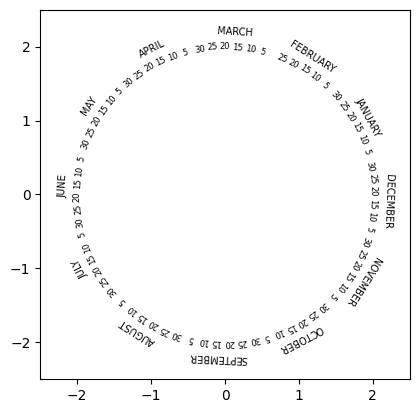

In [5]:
fig, ax = plt.subplots()
ax.set_xlim(-2.5,2.5)
ax.set_ylim(-2.5,2.5)

# Angle of the spring Equinox, which correspond to the 0 RA value
equinox_offest = datetime(2001,3,20).timetuple().tm_yday/365

for m in range(1,13):
    days_in_month = monthrange(2001,m)[1]

    # Plot the day label
    for day in range(5,days_in_month+1,5):
        # Get the angle as a fraction of the whole year
        angle = f*(datetime(2001, m, day).timetuple().tm_yday/365 - equinox_offest)
        a = 2*np.pi*angle
        ax.text(2*np.sin(a), 2*np.cos(a), f'{day}', ha='center', va='center', rotation=-angle*360, fontsize=6)

    # Plot the month label
    angle = f*((datetime(2001, m, 1).timetuple().tm_yday + days_in_month/2)/365 - equinox_offest)
    a = 2*np.pi*angle
    month_name = f'{datetime(2001,m,1).strftime('%B').upper()}'
    ax.text(2.2*np.sin(a), 2.2*np.cos(a), month_name, ha='center', va='center', rotation=-angle*360, fontsize=7)
    
ax.set_aspect('equal')
plt.plot()


In [6]:
Rz = lambda theta: np.array([[np.cos(theta), -np.sin(theta), 0],[np.sin(theta), np.cos(theta), 0 ], [0,0,1]])

Ry = lambda phi: np.array(([[np.cos(phi), 0, np.sin(phi)],[0,1,0], [-np.sin(phi), 0, np.cos(phi)]]))

def sph2cart(long, lat, r=1):
    return r*np.cos(lat)*np.cos(long), r*np.cos(lat)*np.sin(long), r*np.sin(lat)

def cart2sph(v):
    x, y, z = v[0], v[1], v[2]
    return (np.arcsin(z/np.sqrt(x**2+y**2+z**2)), np.arctan2(y,x))

def stereo_polar(lat, long):
    lat, long = np.deg2rad(lat), np.deg2rad(long)
    r = np.tan(np.pi/4-lat/2)

    return (r*np.cos(long), r*np.sin(long))

def stereo_centered(lat, long, lat0, long0):
    lat, long = np.deg2rad(lat), np.deg2rad(long)
    lat0, long0 = np.deg2rad(lat0), np.deg2rad(long0)

    # Rotate the spherical coordinates
    R = np.matmul(Ry(lat0-np.pi/2), Rz(-long0))
    x,y,z = sph2cart(long, lat)
    x,y,z = np.dot(R, (x,y,z))

    # As the values are already in cartesian form, the stereo projection becomes (x/(z+1), y/(z+1))
    # This map has x-positive towards south, y-positive towards west
    # I rotate the plot to have y-positive towards north
    return (-y/(z+1), -x/(z+1))

In [7]:
stereo_polar((70,70,70), (-10,0,10))

(array([0.17364818, 0.17632698, 0.17364818]),
 array([-0.03061886,  0.        ,  0.03061886]))

In [8]:
from HARey_constellation_cards.astro_projection import stereographic_projection
lat, long = np.random.randint(-90,90, size=5000), np.random.randint(-180,180, size=5000)
lat0, long0 = 70, 0
print(stereographic_projection(long0, lat0)(long, lat))
print(stereo_centered(lat, long, lat0, long0))

(array([ 0.38224726,  1.67092898,  0.1410995 , ...,  7.32434305,
       -0.01352642, -0.0464373 ], shape=(5000,)), array([-0.33269411, -4.88216898,  0.11818113, ..., -1.17583939,
        0.86914072,  0.24402069], shape=(5000,)))
(array([ 0.38224726,  1.67092898,  0.1410995 , ...,  7.32434305,
       -0.01352642, -0.0464373 ], shape=(5000,)), array([-0.33269411, -4.88216898,  0.11818113, ..., -1.17583939,
        0.86914072,  0.24402069], shape=(5000,)))


In [9]:
%timeit -n 100 stereographic_projection(long0, lat0)(long, lat)

297 μs ± 87.1 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [10]:
%timeit -n 100 stereo_centered(lat, long, lat0, long0)

275 μs ± 18.2 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


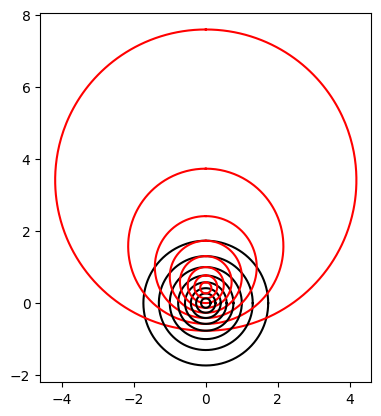

In [11]:
fig, ax = plt.subplots()
phi = np.linspace(0,360,1000)
for theta in range(-30,90,15):

    x,y = stereo_polar(np.full(1000, theta), phi)
    ax.plot(x,y, color='k')

    x,y = stereo_centered(np.full(1000, theta), phi, 45, 180)
    ax.plot(x,y, color='r')

ax.set_aspect('equal')
plt.show()

In [12]:
def azimutal_polar(lat, long):
    lat, long = np.deg2rad(lat), np.deg2rad(long)
    azimut_radius = np.pi/2-lat
    x, y = azimut_radius*np.cos(long), azimut_radius*np.sin(long)
    return -y, x

def project_mask(lat, long, lat0, mode='azimuth'):
    lat, long = np.deg2rad(lat), np.deg2rad(long)
    lat0 = np.deg2rad(lat0)

    # Rotate the spherical coordinates
    x,y,z = sph2cart(long, lat)
    X = np.dot(Ry(np.pi/2-lat0), np.array((x,y,z)))

    if mode == 'azimuth':
        lat, long = cart2sph(X)
        azimut_radius = np.pi/2-lat
        x, y = azimut_radius*np.cos(long), azimut_radius*np.sin(long)

    elif mode == 'stereo':    
        x,y,z = X
        x, y = x/(z+1), y/(z+1)
        
    return -y, x

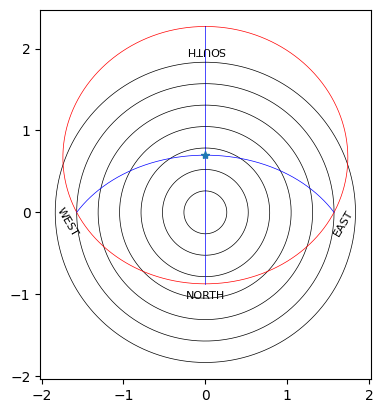

In [13]:
fig, ax = plt.subplots()
phi = np.linspace(0,360,1000)
for theta in range(-15,90,15):
    x,y = azimutal_polar(np.full(1000, theta), phi)
    ax.plot(x,y, color='k', lw=0.5)
    
for theta in range(0,1):
    x,y = project_mask(np.full(1000, theta), phi, 50, mode='azimuth')
    ax.plot(x,y, color='r', lw=0.5)

for phi in range(0,360,90):
    x,y = project_mask(np.linspace(0,90,1000), np.full(1000, phi), 50, mode='azimuth')
    ax.plot(x,y, color='b', lw = 0.5)

x,y = project_mask(90,0,50)
ax.plot(x,y,'*')

# Plot east and west markers
for name, pos in zip(['EAST', 'WEST'], [-90,90]):
    x,y = project_mask((-5, -5),(pos+1,pos-1), 50)
    angle = np.rad2deg(np.arctan2(y[1]-y[0], x[1]-x[0]))
    ax.text(np.mean(x), np.mean(y), name, ha='center', va='top', rotation = angle + np.sign(angle)*180, rotation_mode='anchor', fontsize=8)

x,y = project_mask(-5,180, 50)
ax.text(x,y, 'NORTH', ha='center', va='top', rotation = 0, rotation_mode='anchor', fontsize=8)

x,y = azimutal_polar(-20,0)
ax.text(x,y, 'SOUTH', ha='center', va='top', rotation = 180, rotation_mode='anchor', fontsize=8)


ax.set_aspect('equal')
plt.show()

<function matplotlib.pyplot.plot(*args: 'float | ArrayLike | str', scalex: 'bool' = True, scaley: 'bool' = True, data=None, **kwargs) -> 'list[Line2D]'>

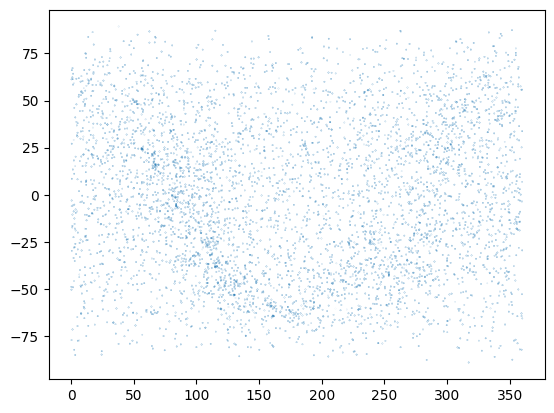

In [14]:
mask = harey.stars.magnitude<6
fig, ax = plt.subplots()
ax.scatter(harey.stars[mask].ra, harey.stars[mask].dec, s=0.001*harey.stars[mask].magnitude**2)
plt.plot

In [15]:
import pandas as pd

hip
88     6.258205
107    5.914268
122   -5.187528
124    0.600590
145    1.886291
154    2.007211
171    1.092216
183    3.674518
194    1.513211
207    0.546112
dtype: float64
hip
88     6.258205
107    5.914268
122   -5.187528
124    0.600590
145    1.886291
154    2.007211
171    1.092216
183    3.674518
194    1.513211
207    0.546112
dtype: float64


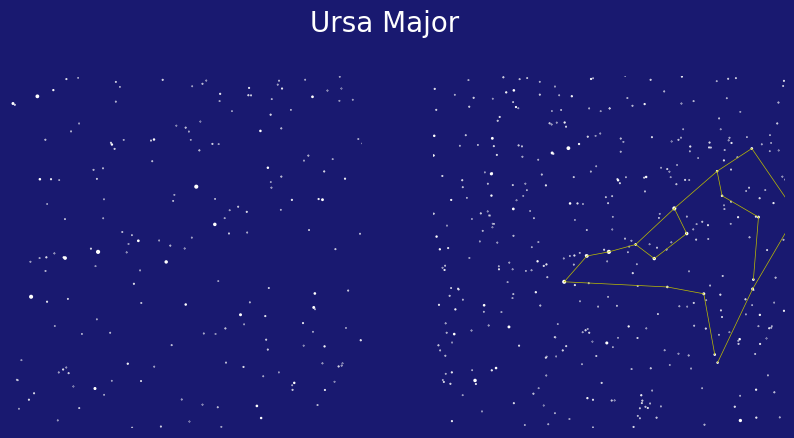

In [16]:
stars = harey.stars[mask]
local_stars = stars.loc[harey.constellations['UMa']['stars']]
brightest_star = local_stars.iloc[np.argmin(local_stars['magnitude'])]

projection = stereographic_projection(brightest_star['ra'], brightest_star['dec'])
stars_x, stars_y = projection(stars['ra'], stars['dec'])
print(stars_y[0:10])
stars_x, stars_y = stereo_centered(stars['dec'], stars['ra'], brightest_star['dec'], brightest_star['ra'])

stars_x, stars_y = pd.Series(stars_x, stars.index), pd.Series(stars_y, stars.index)
print(stars_y[0:10])
fig, (ax1, ax2) = plt.subplots(facecolor='midnightblue', ncols = 2, figsize=(10,5))
fig.suptitle('Ursa Major', color='w', fontsize = 20)
ax1.set_aspect('equal')
ax1.set_axis_off()
ax1.set_xlim(-0.1,0.3)
ax1.set_ylim(-0.2,0.2)

# The stars size is proportional to its brightness
ax1.scatter(stars_x, stars_y, s=20*10**(stars['magnitude']/-2.5), color='w')

ax2.set_aspect('equal')
ax2.set_axis_off()
ax2.set_xlim(-0.3,0.3)
ax2.set_ylim(-0.3,0.3)

# Plot the lines of the constellations Ursa Major
for line in harey.constellations['UMa']['lines']:
    ax2.plot(stars_x[line], stars_y[line], color='y', linewidth=0.5)
    
ax2.scatter(stars_x, stars_y, s=20*10**(stars['magnitude']/-2.5), color='w')
plt.show()



